In [2]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler


In [3]:
df = pd.read_csv('thyroid_dataset.csv')

In [4]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [5]:
X=df.drop("Outlier_label",axis=1)
y = df["Outlier_label"]

In [6]:
scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
if_model = IsolationForest(
    n_estimators=200,
    contamination=.036, # contamination parameter is set to 0.1, meaning we expect 10% of the data to be outliers
    random_state=42
    )

labels = if_model.fit_predict(X_scaled)

Text(0, 0.5, 'Principal Component 2')

<Figure size 800x600 with 0 Axes>

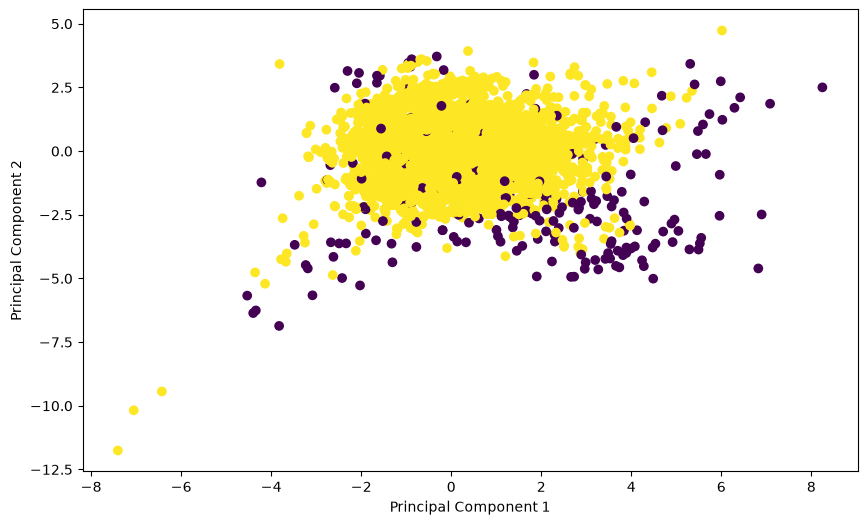

In [8]:
#visualize
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

#visualize
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))

plt.scatter(X_pca[:,0], X_pca[:,1], c = labels)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')


In [9]:
import numpy as np

n_outliers = np.sum(labels == -1)
print(f"Number of outliers detected: {n_outliers}")

n_normmal = np.sum(labels == 1)
print(f"Number of normal points detected: {n_normmal}")

Number of outliers detected: 249
Number of normal points detected: 6667


# Lof local outlier factor 

Text(0, 0.5, 'Principal Component 2')

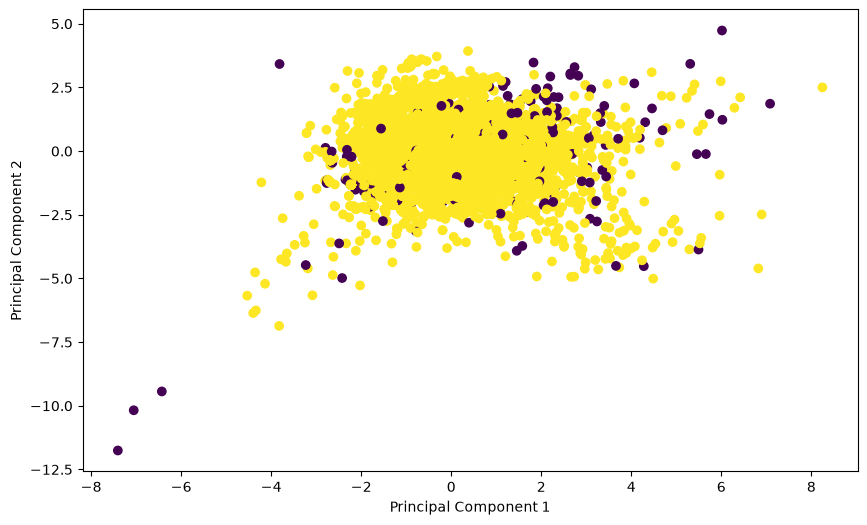

In [12]:
from sklearn.neighbors import LocalOutlierFactor

lof_model = LocalOutlierFactor(contamination=0.036)

labels = lof_model.fit_predict(X_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], c = labels)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

In [13]:
n_outliers = np.sum(labels == -1)
print(f"Number of outliers detected: {n_outliers}")
n_normmal = np.sum(labels == 1)
print(f"Number of normal points detected: {n_normmal}")

Number of outliers detected: 249
Number of normal points detected: 6667
